# Random Forest Classifier

Random Forest is a **Supervised Machine Learning Classification Algorithm**.

It belongs to the **Ensemble Learning** family and is based on **Bagging**.

Instead of building **one Decision Tree**, it builds **many Decision Trees** and combines their predictions.

---

# Intuition

Imagine you ask only one doctor about a disease.

```
Doctor 1

↓

Heart Disease
```

He might be wrong.

Instead, ask 100 doctors.

```
Doctor 1 → Disease

Doctor 2 → Disease

Doctor 3 → Healthy

Doctor 4 → Disease

...

Doctor 100 → Disease
```

Final Decision

```
Majority Vote

↓

Heart Disease
```

This is exactly how **Random Forest** works.

---

# Why is it called Random Forest?

```
Random

↓

Uses random samples of data

+

Random selection of features
```

```
Forest

↓

Many Decision Trees
```

So,

```
Random Data

+

Random Features

+

Many Trees

=

Random Forest
```

---

# Why Not Use One Decision Tree?

A single Decision Tree can easily overfit.

```
Training Accuracy

99%
```

```
Testing Accuracy

82%
```

Random Forest reduces this problem by combining many trees.

---

# How Random Forest Works

```
Original Dataset
        │
        ▼
Bootstrap Sampling
        │
 ┌──────┼────────┐
 │      │        │
 ▼      ▼        ▼
Tree1  Tree2   Tree3
 │      │        │
Random Random  Random
Features Features Features
 │      │        │
 └──────┼────────┘
        ▼
 Majority Vote
        ▼
 Final Prediction
```

---

# Step 1 : Bootstrap Sampling

Random Forest first creates multiple datasets.

Original Dataset

```
1

2

3

4

5
```

Tree 1 gets

```
2

5

1

2

4
```

Tree 2 gets

```
4

3

5

5

2
```

Every tree gets a **different random dataset**.

---

# Step 2 : Random Feature Selection

Suppose our dataset has

```
Age

Blood Pressure

Cholesterol

Smoking

Exercise
```

A Decision Tree checks **all features**.

Random Forest checks only a **random subset**.

Example

Tree 1

```
Age

Smoking
```

Tree 2

```
Blood Pressure

Exercise
```

Tree 3

```
Age

Cholesterol
```

This makes every tree different.

---

# Step 3 : Build Many Trees

```
Dataset

↓

Tree 1

↓

Prediction
```

```
Dataset

↓

Tree 2

↓

Prediction
```

```
Dataset

↓

Tree 3

↓

Prediction
```

Usually,

```
100

200

500

1000

Trees
```

---

# Step 4 : Majority Voting

Suppose

```
Tree 1

↓

Disease
```

```
Tree 2

↓

Healthy
```

```
Tree 3

↓

Disease
```

Final Prediction

```
Disease
```

because

```
Disease = 2 Votes

Healthy = 1 Vote
```

---

# Why Does It Perform Better?

Every tree makes different mistakes.

```
Tree 1

Wrong
```

```
Tree 2

Correct
```

```
Tree 3

Correct
```

Majority voting removes many random errors.

---

# Classification vs Regression

## Random Forest Classifier

Uses

```
Majority Voting
```

Example

```
Disease

Disease

Healthy
```

Prediction

```
Disease
```

---

## Random Forest Regressor

Uses

```
Average
```

Example

```
120

130

140
```

Prediction

```
130
```

---

# Important Hyperparameters

## 1. n_estimators ⭐

Number of Decision Trees.

```python
n_estimators=100
```

More trees

↓

Better accuracy

↓

More computation

---

## 2. criterion

How each tree measures split quality.

```python
criterion="gini"
```

Possible values

```
gini

entropy

log_loss
```

---

## 3. max_depth

Maximum depth of every tree.

```python
max_depth=10
```

Controls overfitting.

---

## 4. min_samples_split

Minimum samples required before splitting.

```python
min_samples_split=5
```

---

## 5. min_samples_leaf

Minimum samples allowed in each leaf.

```python
min_samples_leaf=2
```

---

## 6. max_features ⭐

Number of random features considered at every split.

```python
max_features="sqrt"
```

Common values

```
sqrt

log2

None
```

For classification,

```
sqrt
```

is usually the default and recommended.

---

## 7. bootstrap

Whether bootstrap sampling is used.

```python
bootstrap=True
```

Usually left as

```
True
```

---

## 8. random_state

Ensures reproducible results.

```python
random_state=42
```

---

# Scikit-Learn Syntax

```python
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

---

# Hyperparameter Tuning

```python
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print(grid.best_params_)
```

---

# Feature Importance

One of the biggest advantages of Random Forest is that it tells us **which features are most important**.

Example

```
Age

█████████████
```

```
Cholesterol

████████
```

```
Smoking

██████████████████
```

Scikit-Learn

```python
importance = model.feature_importances_

print(importance)
```

---

# Advantages

✅ High Accuracy

✅ Reduces Overfitting

✅ Handles Non-linear Data

✅ Works well on large datasets

✅ Provides Feature Importance

✅ No Feature Scaling Required

---

# Disadvantages

❌ Slower than a single Decision Tree

❌ Uses more memory

❌ Harder to interpret

❌ Large models take longer to train

---

# Decision Tree vs Random Forest

| Decision Tree | Random Forest |
|--------------|---------------|
| One Tree | Many Trees |
| Overfits Easily | Less Overfitting |
| Fast | Slower |
| Easy to Interpret | Harder to Interpret |
| Lower Accuracy | Higher Accuracy |

---

# Random Forest vs Bagging

Many people think they are the same.

They are **not**.

### Bagging

Every tree uses

```
Random Data
```

but **all features**.

---

### Random Forest

Every tree uses

```
Random Data

+

Random Features
```

This extra randomness makes the trees less similar and usually improves performance.

---

# When Should We Use Random Forest?

Use Random Forest when:

- You need high classification accuracy.
- The dataset contains complex relationships.
- A single Decision Tree is overfitting.
- You want feature importance.
- You have enough computational resources.

Examples:

- Heart Disease Prediction
- Fraud Detection
- Customer Churn Prediction
- Loan Approval
- Cancer Detection

---

# Rule of Thumb

```
Need an Explainable Model?

↓

Decision Tree
```

```
Need Higher Accuracy?

↓

Random Forest
```

```
Need Even Higher Accuracy?

↓

Boosting (XGBoost, LightGBM)
```

---

# Interview Questions

### Why is Random Forest better than a Decision Tree?

Because it combines many Decision Trees trained on different random samples and random subsets of features, reducing overfitting and improving generalization.

---

### Why is it called a Forest?

Because it contains **many Decision Trees**, just like a forest contains many trees.

---

# One-Line Definition

> **Random Forest Classifier is a supervised ensemble learning algorithm that builds multiple Decision Trees using bootstrap samples and random feature selection, then combines their predictions using majority voting to produce a more accurate and robust classifier.**

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline


# we will The Travel Data Set 

In [2]:
df = pd.read_csv("Travel.csv")

```
1.  Load dataset
2.  Basic info — shape, dtypes, info(), describe()
3.  Missing values — isnull().sum()
4.  Duplicates — duplicated().sum()
5.  EDA — value_counts, countplots, boxplots, histograms, heatmap
6.  Fill NaN — median for numeric, mode for categorical
7.  Null check gate — must be zero
8.  Drop useless columns — IDs, names, links, duplicates
9.  Outlier detection — BoxPlots on continuous columns
10. Outlier removal — IQR method
11. Skewness check — .skew() on continuous columns
12. KDE plots — see class separation (classification only)
13. Feature Engineering — create new meaningful features
14. X Y Split — by column name, not iloc
15. Train Test Split — stratify=Y for classification
16. Encoding — ColumnTransformer + OneHotEncoder, fit on train, transform on test
17. Multicollinearity — correlation function on X_train only
18. Scaling — StandardScaler, fit on train, transform on test
19. Train baseline model
20. Train other models
21. Metrics comparison
22. Hyperparameter tuning — RandomizedSearchCV or GridSearchCV
23. ROC AUC — if classification, especially imbalanced
24. Threshold selection — if needed
25. Final model selection — compare CV vs test scores
26. Pickle — save everything
27. Flask app — deploy

In [3]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


``` 
The company is comming up with another service " Wellness Tourisim " and based on Data we will Check wheteher people will take it or not

___
# Data Cleaning 
___

In [4]:
df.shape

(4888, 20)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   str    
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   str    
 7   Gender                    4888 non-null   str    
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   str    
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   str    
 13  NumberOfTrips             4748 non-null   float64
 14  Passport           

In [6]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

```
Check All Categorical Featurs

In [7]:
df["Gender"].unique()

<ArrowStringArray>
['Female', 'Male', 'Fe Male']
Length: 3, dtype: str

In [8]:
# Fix above Female error
df["Gender"] = df["Gender"].replace("Fe Male", "Female")

In [9]:
df["MaritalStatus"].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [10]:
df["MaritalStatus"] = df["MaritalStatus"].replace("Unmarried", "Single")

In [11]:
df["TypeofContact"].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [12]:

df["Occupation"].value_counts()

Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64

In [13]:

df["ProductPitched"].value_counts()

ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64

In [14]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [15]:
df["Gender"].unique()

<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

# Checking Missing Values

In [16]:
features_with_nan = [feature for feature in df.columns if df[feature].isnull().sum() >= 1 ]

for f in features_with_nan:
    print(f, np.round(df[f].isnull().mean()*100, 5), "% missing Values" )

Age 4.62357 % missing Values
TypeofContact 0.51146 % missing Values
DurationOfPitch 5.13502 % missing Values
NumberOfFollowups 0.92062 % missing Values
PreferredPropertyStar 0.53191 % missing Values
NumberOfTrips 2.86416 % missing Values
NumberOfChildrenVisiting 1.35025 % missing Values
MonthlyIncome 4.76678 % missing Values


In [17]:
df[features_with_nan].select_dtypes(exclude="str").describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


# Filling Nan values

```
NUMERIC columns with NaN :
  Age                    → 226 NaN  → fill with median (age has outliers)
  DurationOfPitch        → 251 NaN  → fill with median
  NumberOfFollowups      → 45  NaN  → fill with mode
  PreferredPropertyStar  → 26  NaN  → fill with mode (it is a rating 1-5)
  NumberOfTrips          → 140 NaN  → fill with median
  NumberOfChildrenVisiting → 66 NaN → fill with median
  MonthlyIncome          → 233 NaN  → fill with median (income has outliers)

CATEGORICAL columns with NaN :
  TypeofContact          → 25  NaN  → fill with mode (most frequent value)

In [18]:
# median is better than mean for columns with potential outliers
# median is not affected by extreme values

num_cols_to_fill = ["Age", "DurationOfPitch","NumberOfTrips", "NumberOfChildrenVisiting", "MonthlyIncome"]

for col in num_cols_to_fill:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col:30} → filled with median: {median_val}")

Age                            → filled with median: 36.0
DurationOfPitch                → filled with median: 13.0
NumberOfTrips                  → filled with median: 3.0
NumberOfChildrenVisiting       → filled with median: 1.0
MonthlyIncome                  → filled with median: 22347.0


In [19]:
# PreferredPropertyStar is a rating (1-5) — mode makes more sense than median
mode_val = df["PreferredPropertyStar"].mode()[0]
df["PreferredPropertyStar"] = df["PreferredPropertyStar"].fillna(mode_val)
print(f"PreferredPropertyStar → filled with mode: {mode_val}")

PreferredPropertyStar → filled with mode: 3.0


In [20]:
mode_contact = df["TypeofContact"].mode()[0]
df["TypeofContact"] = df["TypeofContact"].fillna(mode_contact)
print(f"TypeofContact → filled with mode: {mode_contact}")

TypeofContact → filled with mode: Self Enquiry


In [21]:
mode_followups = df["NumberOfFollowups"].mode()[0]
df["NumberOfFollowups"] = df["NumberOfFollowups"].fillna(mode_followups)
print(f"NumberOfFollowups → filled with mode: {mode_followups}")

NumberOfFollowups → filled with mode: 4.0


In [22]:
print(df.isnull().sum())
print()
total = df.isnull().sum().sum()
print(f"Total NaN remaining: {total}")

if total == 0:
    print("✅ All clean — safe to check outliers and skewness now")
else:
    print("❌ Fix remaining NaN before proceeding")

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

Total NaN remaining: 0
✅ All clean — safe to check outliers and skewness now


In [23]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


___
# Feature Engineering

    Droping Useless Cols 
___

In [24]:
# check dtypes
df.dtypes

CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                   str
CityTier                      int64
DurationOfPitch             float64
Occupation                      str
Gender                          str
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched                  str
PreferredPropertyStar       float64
MaritalStatus                   str
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                     str
MonthlyIncome               float64
dtype: object

In [25]:
# CustomerID is just an identifier — no predictive value
df.drop("CustomerID", axis=1, inplace=True)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (4888, 19)
Columns: ['ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar', 'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome']


In [26]:
df["TotalVisiting"] = df["NumberOfPersonVisiting"] + df["NumberOfChildrenVisiting"]

df.drop(["NumberOfPersonVisiting", "NumberOfChildrenVisiting" ], axis = 1, inplace = True)

In [27]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Single,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Single,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


___
# Outlier and Skewness removal 
___

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ProdTaken               4888 non-null   int64  
 1   Age                     4888 non-null   float64
 2   TypeofContact           4888 non-null   str    
 3   CityTier                4888 non-null   int64  
 4   DurationOfPitch         4888 non-null   float64
 5   Occupation              4888 non-null   str    
 6   Gender                  4888 non-null   str    
 7   NumberOfFollowups       4888 non-null   float64
 8   ProductPitched          4888 non-null   str    
 9   PreferredPropertyStar   4888 non-null   float64
 10  MaritalStatus           4888 non-null   str    
 11  NumberOfTrips           4888 non-null   float64
 12  Passport                4888 non-null   int64  
 13  PitchSatisfactionScore  4888 non-null   int64  
 14  OwnCar                  4888 non-null   int64  
 15

```
separeting Featurs

In [29]:
num_features = [col for col in df.columns if df[col].dtype != 'string']

print("Number of Numerical Features:", num_features)

Number of Numerical Features: ['ProdTaken', 'Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisiting']


In [30]:
# Categorical Features 
cat_features = [col for col in df.columns if df[col].dtype == 'string']

print("Number of categorical Features:", cat_features)

Number of categorical Features: ['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation']


In [31]:
# discrete fetaures :: have fixed number of categories i.e 25 categories
# 
discrete_features = [col for col in num_features if len(df[col].unique()) <= 25 ]

print("Number of Discrete Features:", discrete_features)


Number of Discrete Features: ['ProdTaken', 'CityTier', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'TotalVisiting']


In [32]:
con_features = [col for col in num_features if col not in discrete_features ]

print("Number of continues Features:", con_features)

Number of continues Features: ['Age', 'DurationOfPitch', 'MonthlyIncome']


```
Checking Outlier Using Box Plot 

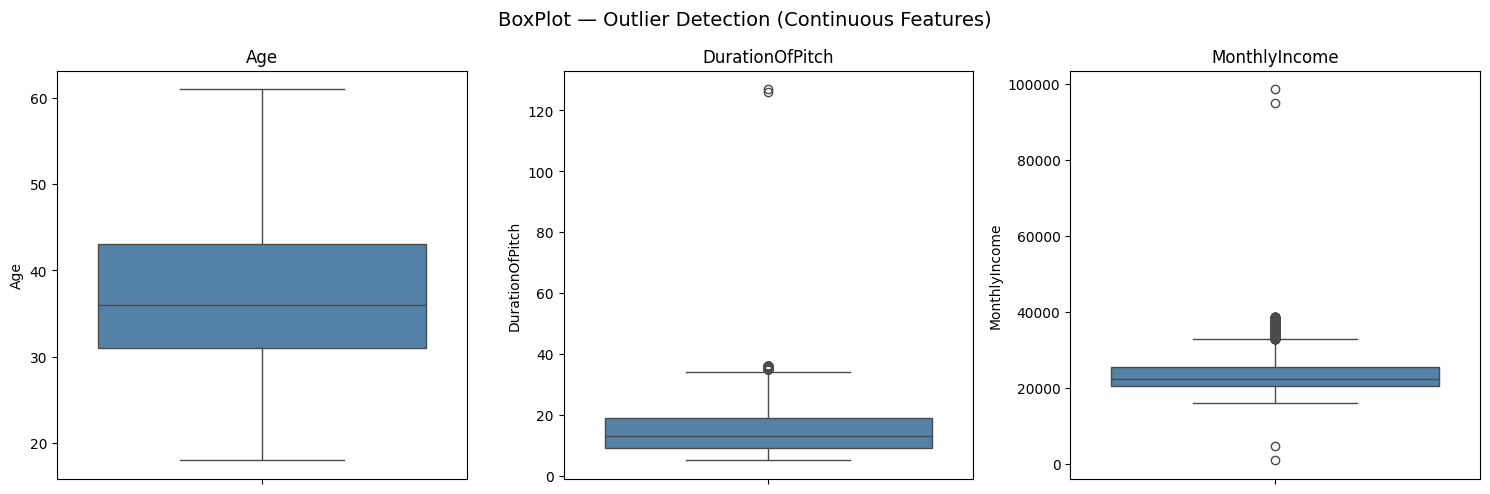

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

con_features = ["Age", "DurationOfPitch", "MonthlyIncome"]

for i, col in enumerate(con_features):
    sns.boxplot(data=df, y=col, ax=axes[i], color="steelblue")
    axes[i].set_title(col)

plt.suptitle("BoxPlot — Outlier Detection (Continuous Features)", fontsize=14)
plt.tight_layout()
plt.show()

In [34]:
print("Skewness Check:")
print()
for col in con_features:
    skew = df[col].skew()
    print(f"{col:20} → skewness: {skew:.4f}  {'⚠️ skewed' if abs(skew) > 1 else '✅ ok'}")

Skewness Check:

Age                  → skewness: 0.4158  ✅ ok
DurationOfPitch      → skewness: 1.8318  ⚠️ skewed
MonthlyIncome        → skewness: 2.0233  ⚠️ skewed


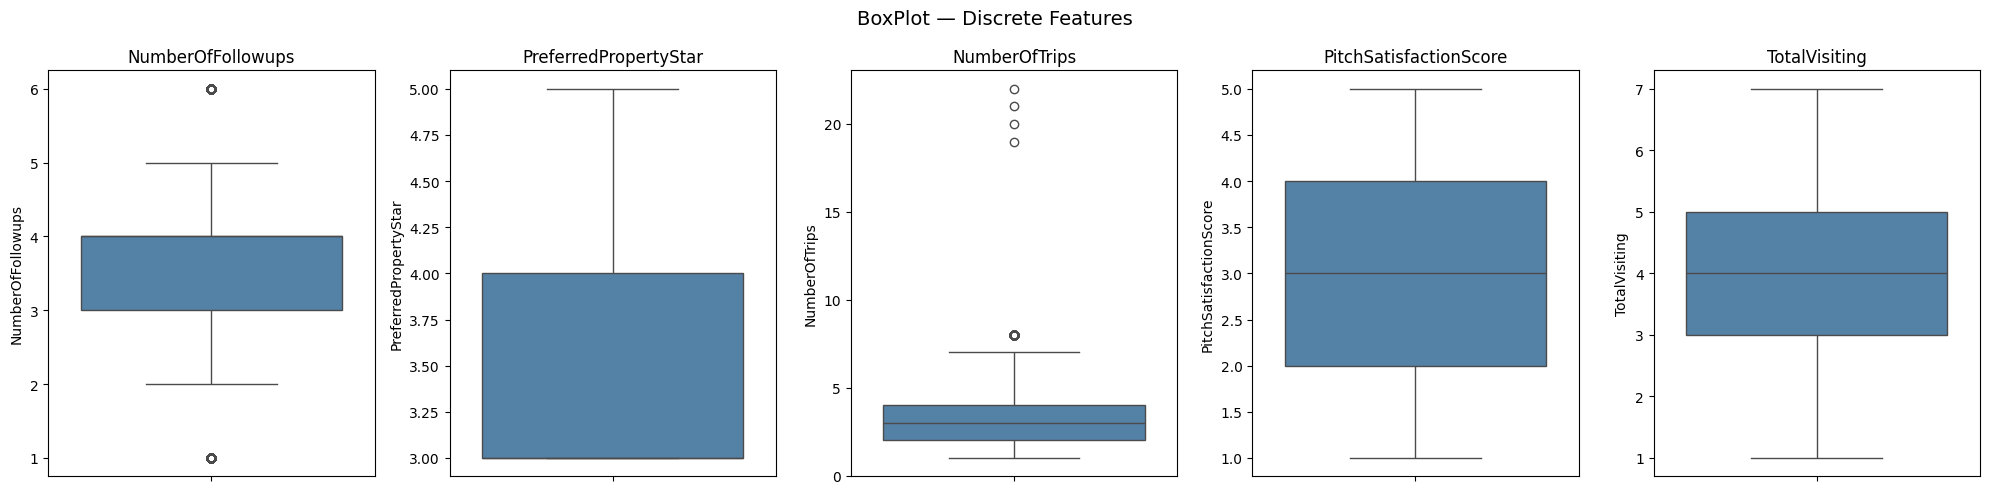

In [35]:
discrete_features = ['NumberOfFollowups', 'PreferredPropertyStar', 
                     'NumberOfTrips', 'PitchSatisfactionScore', 'TotalVisiting']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(discrete_features):
    sns.boxplot(data=df, y=col, ax=axes[i], color="steelblue")
    axes[i].set_title(col)

plt.suptitle("BoxPlot — Discrete Features", fontsize=14)
plt.tight_layout()
plt.show()

In [36]:
outlier_cols = ["DurationOfPitch", "MonthlyIncome", "NumberOfTrips", "NumberOfFollowups"]

print("Before:", df.shape)
print()

for col in outlier_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before = df.shape[0]
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    after = df.shape[0]

    print(f"{col:25} → Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}  removed {before - after} rows")

df.reset_index(drop=True, inplace=True)
print()
print("After:", df.shape)

Before: (4888, 18)

DurationOfPitch           → Q1=9.0  Q3=19.0  IQR=10.0  removed 112 rows
MonthlyIncome             → Q1=20465.2  Q3=25400.8  IQR=4935.5  removed 369 rows
NumberOfTrips             → Q1=2.0  Q3=4.0  IQR=2.0  removed 103 rows
NumberOfFollowups         → Q1=3.0  Q3=4.0  IQR=1.0  removed 281 rows

After: (4023, 18)


```
checking skewness 

In [37]:
print("Skewness after IQR removal:")
print()
for col in ["Age", "DurationOfPitch", "MonthlyIncome"]:
    skew = df[col].skew()
    print(f"{col:20} → skewness: {skew:.4f}  {'⚠️ still skewed' if abs(skew) > 1 else '✅ ok'}")

Skewness after IQR removal:

Age                  → skewness: 0.5244  ✅ ok
DurationOfPitch      → skewness: 0.9263  ✅ ok
MonthlyIncome        → skewness: 0.6687  ✅ ok


```
Box Plot after IQR removal 

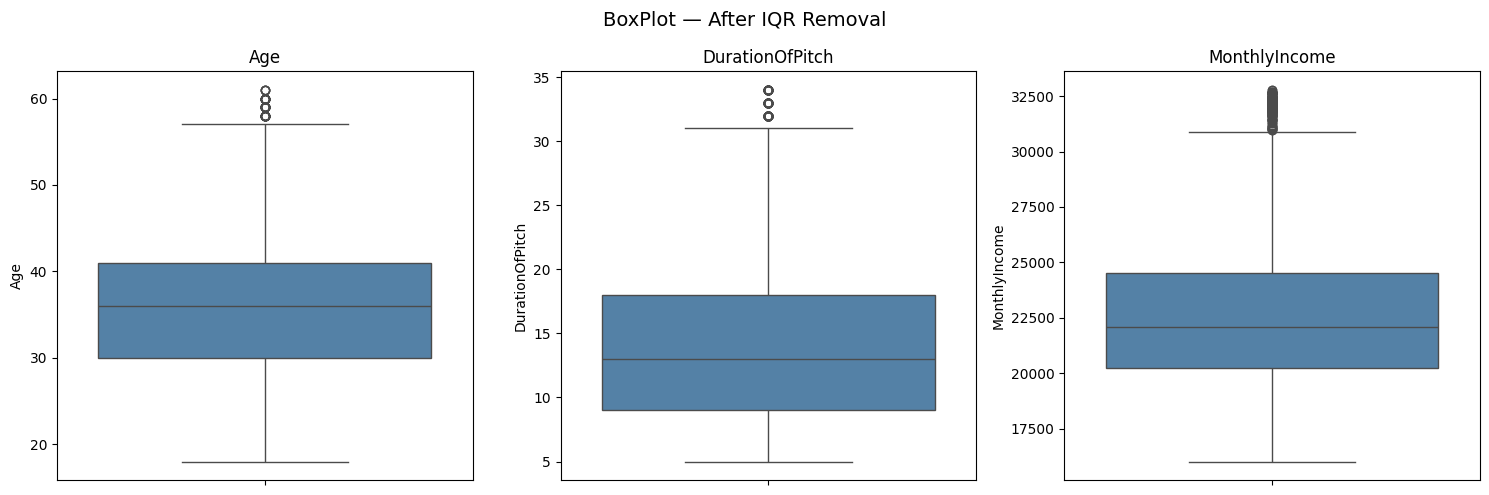

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(["Age", "DurationOfPitch", "MonthlyIncome"]):
    sns.boxplot(data=df, y=col, ax=axes[i], color="steelblue")
    axes[i].set_title(col)

plt.suptitle("BoxPlot — After IQR Removal", fontsize=14)
plt.tight_layout()
plt.show()

___
# X , Y Split 

    ProdTaken is our Output feature ... we need to predict wheter customer will take the new product or not 
___

In [39]:
X = df.drop("ProdTaken", axis = 1)
y = df["ProdTaken"]



___
# Train Test Split 
___

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 42, stratify = y)

In [42]:
X_train.shape

(2816, 17)

# Encoding

In [43]:
for i, col in enumerate(X_train.columns):
    print(f"{i}; {col}")


0; Age
1; TypeofContact
2; CityTier
3; DurationOfPitch
4; Occupation
5; Gender
6; NumberOfFollowups
7; ProductPitched
8; PreferredPropertyStar
9; MaritalStatus
10; NumberOfTrips
11; Passport
12; PitchSatisfactionScore
13; OwnCar
14; Designation
15; MonthlyIncome
16; TotalVisiting


In [44]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[
        ("OneHot", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), [1, 4, 5, 7, 9, 14])
        # TypeofContact=1, Occupation=4, Gender=5, ProductPitched=7, MaritalStatus=9, Designation=14
    ],
    remainder="passthrough"
)

X_train = ct.fit_transform(X_train)
X_test  = ct.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)

X_train shape: (2816, 24)
X_test  shape: (1207, 24)


/home/aizen/AI_ML/env/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [3, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [45]:
ohe_cols  = ct.named_transformers_["OneHot"].get_feature_names_out(
    ["TypeofContact", "Occupation", "Gender", "ProductPitched", "MaritalStatus", "Designation"]
)
pass_cols = ["Age", "CityTier", "DurationOfPitch", "NumberOfFollowups",
             "PreferredPropertyStar", "NumberOfTrips", "Passport",
             "PitchSatisfactionScore", "OwnCar", "MonthlyIncome", "TotalVisiting"]

all_cols = list(ohe_cols) + pass_cols

X_train = pd.DataFrame(X_train, columns=all_cols)
X_test  = pd.DataFrame(X_test,  columns=all_cols)

print("Total features:", len(all_cols))
X_train.head()

Total features: 24


,TypeofContact_Self Enquiry,Occupation_Large Business,Occupation_Salaried,Occupation_Small Business,Gender_Male,ProductPitched_Deluxe,ProductPitched_Standard,ProductPitched_Super Deluxe,MaritalStatus_Married,MaritalStatus_Single,...,CityTier,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,MonthlyIncome,TotalVisiting
0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,23.0,2.0,3.0,3.0,1.0,3.0,0.0,21613.0,7.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,13.0,5.0,3.0,2.0,0.0,2.0,1.0,20865.0,6.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,15.0,3.0,4.0,2.0,0.0,3.0,0.0,17279.0,5.0
3,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,13.0,3.0,5.0,2.0,0.0,2.0,1.0,20210.0,5.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,7.0,4.0,3.0,2.0,0.0,5.0,1.0,29180.0,5.0


___
# Checking Multi co linealrity 

     rmove hghly co related featured

___

In [46]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    return col_corr

corr_features = correlation(X_train, 0.85)
print("Highly correlated features to drop:", corr_features)

Highly correlated features to drop: {'Designation_Senior Manager', 'Designation_Manager'}


In [47]:
# only run if corr_features is NOT empty
if corr_features:
    X_train.drop(corr_features, axis=1, inplace=True)
    X_test.drop(corr_features, axis=1, inplace=True)
    print("Dropped:", corr_features)
    print("X_train shape:", X_train.shape)
else:
    print("✅ No multicollinearity — nothing to drop")

Dropped: {'Designation_Senior Manager', 'Designation_Manager'}
X_train shape: (2816, 22)


___
# Scalling 
___

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled  shape:", X_test_scaled.shape)

Scaling done
X_train_scaled shape: (2816, 22)
X_test_scaled  shape: (1207, 22)


___
# Model Traing 
___

In [49]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# train
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# predict
y_pred_rf = rf.predict(X_test_scaled)

# metrics
print("=" * 50)
print("  Random Forest Classifier")
print("=" * 50)
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

  Random Forest Classifier
  Accuracy: 0.9246

              precision    recall  f1-score   support

           0       0.93      0.98      0.95       977
           1       0.91      0.67      0.77       230

    accuracy                           0.92      1207
   macro avg       0.92      0.83      0.86      1207
weighted avg       0.92      0.92      0.92      1207


Confusion Matrix:
[[962  15]
 [ 76 154]]


```
Class 0 recall : 1.00  →  catches ALL non-buyers
Class 1 recall : 0.58  →  misses 92 out of 217 actual buyers ← problem

92 customers who WOULD buy the package went undetected
The sales team never reached out to them → lost revenue

___
# Hyper Parameter Tuning 
___

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

rf_model = RandomForestClassifier(random_state=42)

params = {
    "n_estimators"   : [50, 100, 200, 300],
    "max_depth"      : [5, 10, 15, 20, None],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf"  : [1, 2, 5],
    "class_weight"   : ["balanced", None, {0:1, 1:2}, {0:1, 1:3}]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_rf = RandomizedSearchCV(
    estimator           = rf_model,
    param_distributions = params,
    n_iter              = 20,
    scoring             = "f1",        # not accuracy — imbalanced data
    cv                  = cv,
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1
)

random_rf.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced', None, ...], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used h

In [52]:
random_rf.best_params_

{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_depth': 15,
 'class_weight': 'balanced'}

In [53]:
random_rf.best_score_

np.float64(0.6830106443003172)

In [54]:
y_pred_rf_tuned = random_rf.predict(X_test_scaled)

print("=" * 50)
print("  Random Forest — Tuned")
print("=" * 50)
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print()
print(classification_report(y_test, y_pred_rf_tuned))

# compare class 1 recall vs basic model
# basic was 0.58 — tuned should be higher

  Random Forest — Tuned
  Accuracy: 0.9163

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       977
           1       0.84      0.69      0.76       230

    accuracy                           0.92      1207
   macro avg       0.89      0.83      0.85      1207
weighted avg       0.91      0.92      0.91      1207



____
____
____

# Trainig Other Models 

___
___
___


In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# all models in one dictionary
models = {
    "Decision Tree"       : DecisionTreeClassifier(random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression" : LogisticRegression(max_iter=1000),
    "SVC Linear"          : SVC(kernel="linear", probability=True),
    "SVC RBF"             : SVC(kernel="rbf", probability=True),
    "KNN"                 : KNeighborsClassifier(n_neighbors=5),
    "Gaussian NB"         : GaussianNB(),
    "RF Tuned"            : random_rf.best_estimator_,
}

# train all, predict all, store results
results = {}

for name, model in models.items():
    
    # skip RF Tuned — already fitted
    if name != "RF Tuned":
        model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    acc  = accuracy_score(y_test, y_pred)
    results[name] = {"y_pred": y_pred, "accuracy": acc}

# print comparison table
print(f"{'Model':<25} {'Accuracy':<12} {'Recall(1)':<12} {'F1(1)':<10}")
print("-" * 59)

from sklearn.metrics import recall_score, f1_score

for name, res in results.items():
    acc = res["accuracy"]
    rec = recall_score(y_test, res["y_pred"])
    f1  = f1_score(y_test, res["y_pred"])
    print(f"{name:<25} {acc:<12.4f} {rec:<12.4f} {f1:<10.4f}")

Model                     Accuracy     Recall(1)    F1(1)     
-----------------------------------------------------------
Decision Tree             0.8923       0.7043       0.7137    
Random Forest             0.9246       0.6696       0.7719    
Logistic Regression       0.8426       0.3435       0.4540    
SVC Linear                0.8094       0.0000       0.0000    
SVC RBF                   0.8766       0.4652       0.5895    
KNN                       0.8865       0.5609       0.6532    
Gaussian NB               0.7920       0.6087       0.5273    
RF Tuned                  0.9163       0.6913       0.7589    
